In [1]:
import globals as gl
import pickle

import nibabel as nb
import nitools as nt

from matplotlib.cm import ScalarMappable

import os
import numpy as np
import sys

import PcmPy as pcm

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import surfAnalysisPy as surf

import rsatoolbox as rsa

import warnings
warnings.filterwarnings("ignore")

plt.close('all')
plt.style.use('default')


Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


# Behaviour

## Reaction time

loading subj102
loading subj103
loading subj104
loading subj105
loading subj106
loading subj107
loading subj108


Text(0.5, 1.0, 'Reaction time (cue collapsed)')

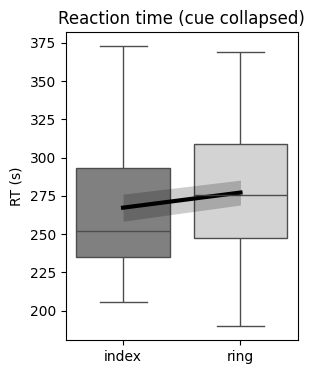

In [3]:
snS = [102, 103, 104, 105, 106, 107, 108]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(figsize=(3, 4))

sns.boxplot(data=df[df['GoNogo'] == 'go'], x='stimFinger', y='RT', palette=['grey', 'lightgrey'])
sns.lineplot(data=df[df['GoNogo'] == 'go'], x='stimFinger', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)

axs.set_ylabel('RT (s)')
axs.set_xlabel('')

axs.set_title('Reaction time (cue collapsed)')

loading subj102
loading subj103
loading subj104
loading subj105
loading subj106
loading subj107
loading subj108


Text(0.5, 1.0, 'Reaction time (stimFinger collapsed)')

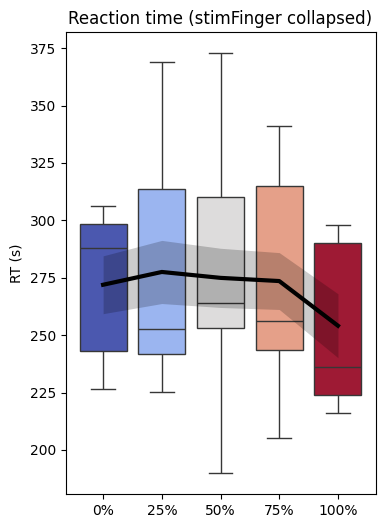

In [4]:
snS = [102, 103, 104, 105, 106, 107, 108]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(figsize=(4, 6))

sns.boxplot(data=df[df['GoNogo'] == 'go'], x='cue', y='RT', order=gl.cues, palette=list(gl.colour_mapping.values())[:5])
sns.lineplot(data=df[df['GoNogo'] == 'go'], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)

axs.set_ylabel('RT (s)')
axs.set_xlabel('')

axs.set_title('Reaction time (stimFinger collapsed)')

Text(0.5, 0.98, 'Reaction time (stratified by stimFinger)')

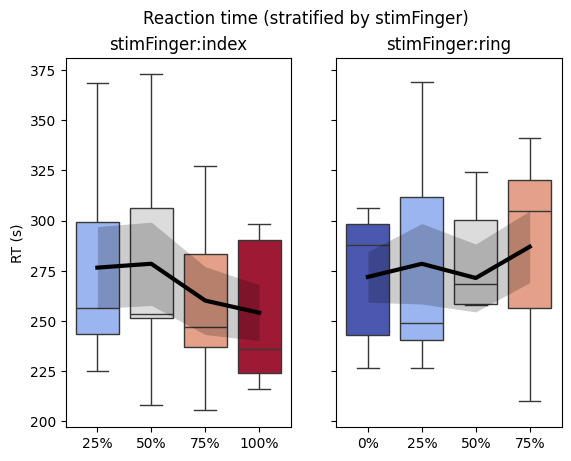

In [5]:
fig, axs = plt.subplots(1, 2, sharey=True)

sns.boxplot(
    ax = axs[0],
    data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'index')],
    x='cue',
    y='RT',
    order=gl.cues,
    palette=list(gl.colour_mapping.values())[:5],
    showfliers=False,
)

sns.boxplot(
    ax = axs[1],
    data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'ring')],
    x='cue',
    y='RT',
    order=gl.cues,
    palette=list(gl.colour_mapping.values())[:5],
    showfliers=False,
)

sns.lineplot(ax=axs[0], data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'index')], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)
sns.lineplot(ax=axs[1], data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'ring')], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)

axs[0].set_ylabel('RT (s)')
axs[0].set_xlabel('')
axs[1].set_xlabel('')

axs[0].set_title('stimFinger:index')
axs[1].set_title('stimFinger:ring')

fig.suptitle('Reaction time (stratified by stimFinger)')

## Force response

Text(0.5, 0.01, 'time relative to perturbation onset (s)')

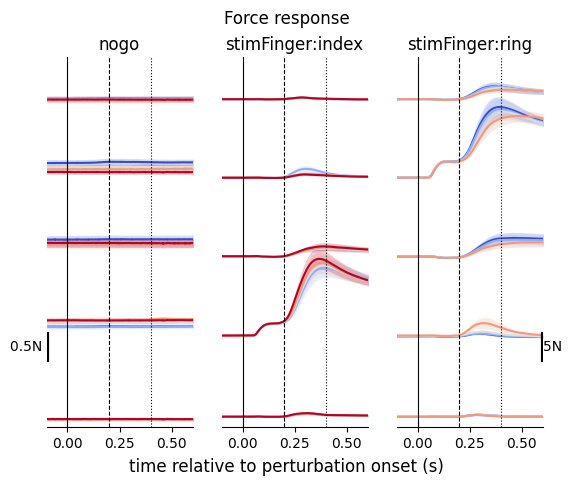

In [97]:
from myplot import make_yref

experiment = 'smp2'

npz = np.load(os.path.join(gl.baseDir, experiment, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

fig, axs = plt.subplots(ncols=3, sharex=True,)

vsep_go = 15
vsep_nogo = 1.5

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        if stimF != 'nogo':
            axs[sf].set_title(f'stimFinger:{stimF}')
        else:
            axs[sf].set_title('nogo')
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[c])
            axs[sf].fill_between(tAx, force_avg + f * vsep_go - force_err, force_avg + f * vsep_go + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[0].plot(tAx, force_avg + f * vsep_nogo, color=list(gl.colour_mapping.values())[c])
            axs[0].fill_between(tAx, force_avg + f * vsep_nogo - force_err, force_avg + f * vsep_nogo + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for ax in axs:
    ax.axvline(.2, color='k', ls='--', lw=.8)
    ax.axvline(.4, color='k', ls=':', lw=.8)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])

axs[0].set_xlim([-.1, .6])
axs[0].set_ylim([-.21, 6.90])
axs[1].set_ylim([-2, 68])
axs[2].set_ylim([-2, 68])

make_yref(axs[2], reference_length=5, pos='right')
make_yref(axs[0], reference_length=.5, pos='left')

fig.suptitle('Force response')
fig.supxlabel('time relative to perturbation onset (s)')

loading subj102
loading subj103
loading subj104
loading subj105
loading subj106
loading subj107
loading subj108


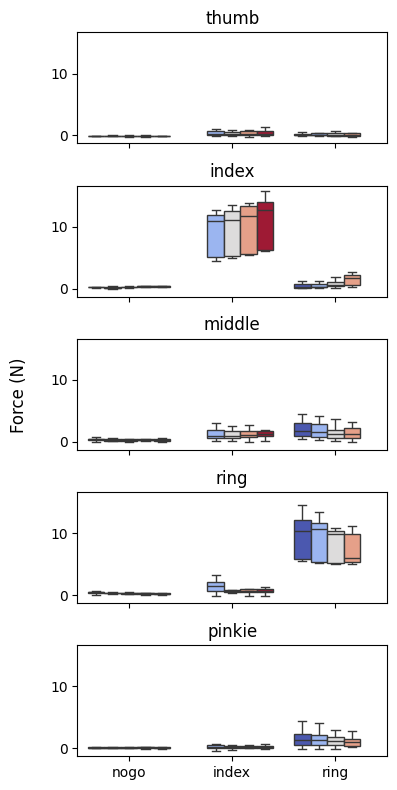

In [98]:
snS = [102, 103, 104, 105, 106, 107, 108]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)
    
fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(4, 8))
    

for f, finger in enumerate(gl.channels['mov']):

    sns.boxplot(x='stimFinger', y=finger, ax=axs[f], hue='cue', data=df,  showfliers=False,  legend=False, order=['nogo', 'index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5])
    
    axs[f].set_xlabel('')
    axs[f].set_ylabel('')
    axs[f].set_title(finger)

fig.supylabel('Force (N)')
fig.tight_layout()

## Muscle activity (Experiment 1)

Text(0.5, 0.98, 'EMG, average distances across participants (N=10)')

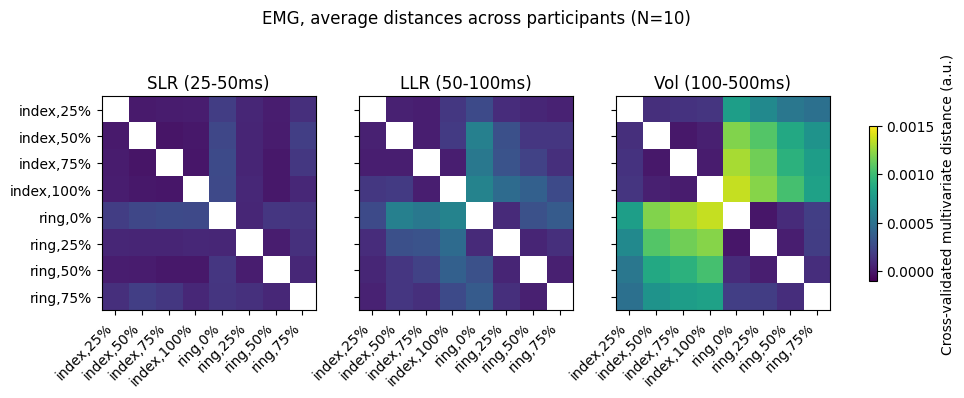

In [6]:
experiment = 'smp0'
vmin, vmax = -1e-4, 1.5e-3
snS=[100, 101, 102, 104, 105, 106, 107, 108, 109, 110]

r = 0

fig, axs = plt.subplots(ncols=3, sharex=True, sharey=True, figsize=(10, 4))

timepoints = ['SLR', 'LLR', 'Vol']
twins = ['25-50ms', '50-100ms', '100-500ms']

for col in range(3):
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', 'emg.hdf5'))
        rdm = rdm.subset('timepoint', timepoints[col])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[col], rdm_descriptor='timepoint', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[col].set_yticks(axs[col].get_xticks())
    axs[col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[col].set_title(f'{timepoints[col]} ({twins[col]})')

cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.01)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'EMG, average distances across participants (N={len(snS)})')

In [ ]:
glm = 12
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(5, 6))
sn = 102
experiment = 'smp2'
dtype = 'con'

vmin, vmax = -20, 20

xlim = {
    'L': [-80, 120],
    'R': [-120, 80],
}
ylim = {
    'L': [-50, 150],
    'R':[-60, 140]
}

for H, Hem in enumerate(['L', 'R']):

    data = os.path.join(gl.baseDir, experiment, gl.wbDir, f'subj{sn}', f'glm{glm}.{dtype}.{Hem}.func.gii')
    
    D = nb.load(data)
    darray = nt.get_gifti_data_matrix(D)
    
    col_names = nt.get_gifti_column_names(D)
    
    plan_col_names = [f'con_{col}.nii' for col in ['0%', '25%', '50%', '75%', '100%']]
    exec_col_names = [f'con_{col}.nii' for col in ['0%,index', '25%,index', '50%,index', '75%,index', '100%,index', '0%,ring', '25%,ring', '50%,ring', '75%,ring', '100%,ring']]
    
    im = np.array([x in plan_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[0, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])
    
    im = np.array([x in exec_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[1, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='jet')
cbar = fig.colorbar(sm, ax=[axs[1, 0], axs[1, 1]], orientation='horizontal', fraction=0.03)
cbar.set_label('t-value')

# cosmetic
axs[0, 0].set_title('Left hemisphere\nPlanning')
axs[0, 1].set_title('Right hemisphere\nPlanning')
axs[1, 0].set_title('Execution')
axs[1, 1].set_title('Execution')

fig.suptitle('Average activity during planning and execution')
fig.subplots_adjust(top=0.85, bottom=.2)

# Average activation in ROIs

## Planning

Text(0.5, 0.98, 'Average planning activity across participants (N=6), hemisphere:L')

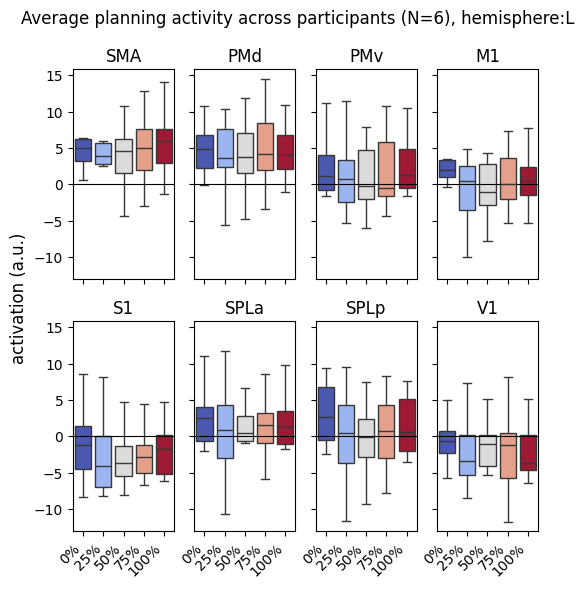

In [6]:
experiment = 'smp2'
snS = [102, 103, 104, 105, 106, 107]
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

conditions = ['0%','25%', '50%', '75%', '100%']

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, 'ROI.con.avg.tsv'), sep='\t')
df_con['condition'] = df_con['condition'].str.replace(" ", "")
df_con['sn'] = df_con['sn'].astype(str)
df_con = df_con[df_con['condition'].isin(conditions)]
df_con = df_con.groupby(['condition', 'roi', 'Hem', 'sn']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(6, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    sns.boxplot(df_con[df_con['roi'] == roi],
                ax=axs[row, col],
                y='activity',
                x='condition',
                order=conditions,
                palette=[gl.colour_mapping[cond] for cond in conditions],
                showfliers=False)
    
    axs[row, col].axhline(0, ls='-', color='k', lw=.8)
    axs[row, col].set_title(roi)
    axs[row, col].set_ylabel('')
    axs[row, col].set_xlabel('')
    axs[row, col].tick_params(axis='x', rotation=45)
    plt.setp(axs[row, col].get_xticklabels(), ha='right')

fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average planning activity across participants (N={len(snS)}), hemisphere:{Hem}')

# Execution

Text(0.5, 0.98, 'Average execution activity across participants (N=6), hemisphere:L')

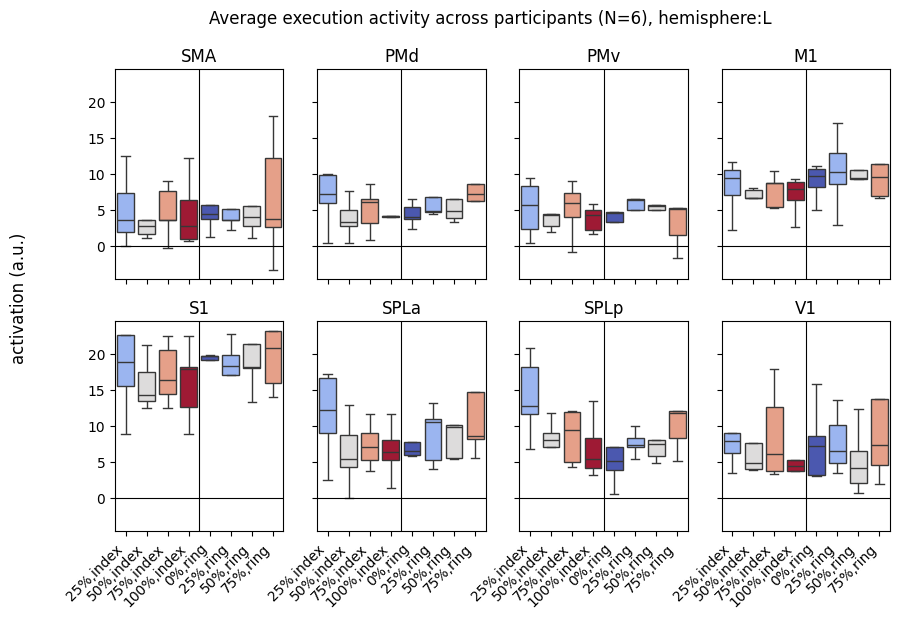

In [8]:
experiment = 'smp2'
snS = [102, 103, 104, 105, 106, 107]
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

conditions = ['25%,index', '50%,index', '75%,index', '100%,index',
              '0%,ring', '25%,ring', '50%,ring', '75%,ring']

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, 'ROI.con.avg.tsv'), sep='\t')
df_con['condition'] = df_con['condition'].str.replace(" ", "")
df_con['sn'] = df_con['sn'].astype(str)
df_con = df_con[df_con['condition'].isin(conditions)]
df_con = df_con.groupby(['condition', 'roi', 'Hem', 'sn']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    sns.boxplot(df_con[(df_con['roi'] == roi) & (df_con['Hem'] == Hem)],
                ax=axs[row, col],
                y='activity',
                x='condition',
                order=conditions,
                palette=[gl.colour_mapping[cond] for cond in conditions],
                showfliers=False)
    
    axs[row, col].axhline(0, ls='-', color='k', lw=.8)
    axs[row, col].axvline(3.5, ls='-', color='k', lw=.8)
    axs[row, col].set_title(roi)
    axs[row, col].set_ylabel('')
    axs[row, col].set_xlabel('')
    axs[row, col].tick_params(axis='x', rotation=45)
    plt.setp(axs[row, col].get_xticklabels(), ha='right')

fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average execution activity across participants (N={len(snS)}), hemisphere:{Hem}')

 # **Cue representation**

## **Planning**

Text(0.5, 0.98, 'Planning, average distances across participants (N=6), hemisphere:L')

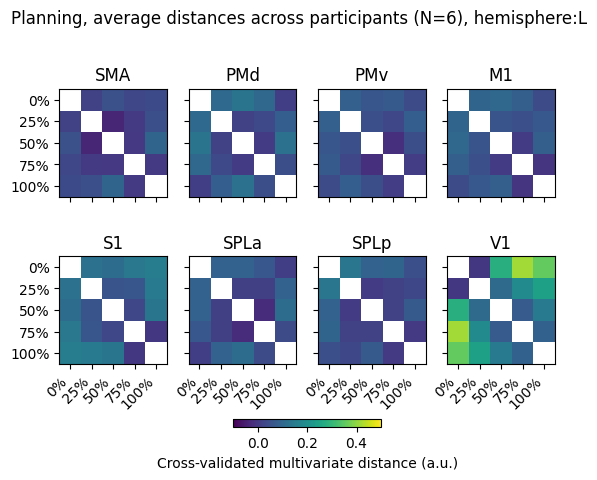

In [9]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
snS=[102, 103, 104, 105, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Planning, average distances across participants (N={len(snS)}), hemisphere:{Hem}')

## **Execution**

Text(0.5, 0.98, 'Execution, average distances across participants (N=5), hemisphere:L')

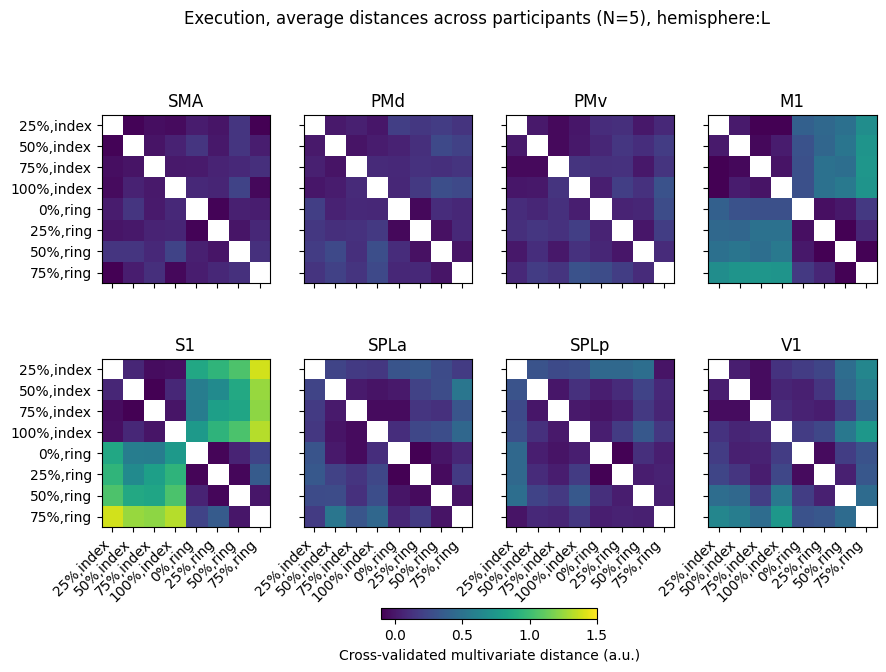

In [10]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1.5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Execution, average distances across participants (N={len(snS)}), hemisphere:{Hem}')


# Models

## Planning

Text(0.5, 0.98, 'Planning models')

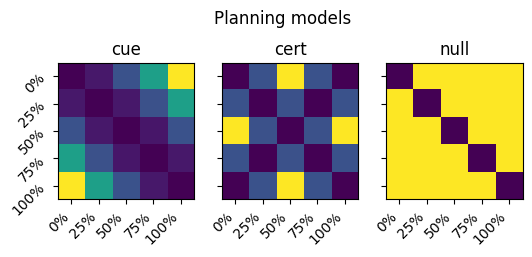

In [11]:
C = pcm.centering(5)

v_cue =  C @ np.array([-2, -1, 0, 1, 2]) 
v_cert = C @ np.array([0, 1, 2, 1, 0])

G_cue = np.outer(v_cue, v_cue)

G_cert = np.outer(v_cert, v_cert)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(6, 2.5))

axs[0].imshow(pcm.G_to_dist(G_cue))
axs[1].imshow(pcm.G_to_dist(G_cert))
axs[2].imshow(pcm.G_to_dist(np.eye(5)))

axs[0].set_title('cue')
axs[1].set_title('cert')
axs[2].set_title('null')

for ax in axs:
    ax.set_xticks(np.arange(len(gl.cues)))
    ax.set_xticklabels(gl.cues, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(gl.cues)))
    ax.set_yticklabels(gl.cues, rotation=45, ha='right')

fig.suptitle('Planning models')

noise upper: 27.46, noise lower: 15.74
noise upper: 130.81, noise lower: 82.78
noise upper: 27.86, noise lower: 8.63
noise upper: 43.22, noise lower: 19.62
noise upper: 121.27, noise lower: 63.00
noise upper: 61.20, noise lower: 21.98
noise upper: 75.66, noise lower: 25.40
noise upper: 823.92, noise lower: 786.42


Text(0.5, 1.0, 'Marginal likelihood relative to null model (planning)')

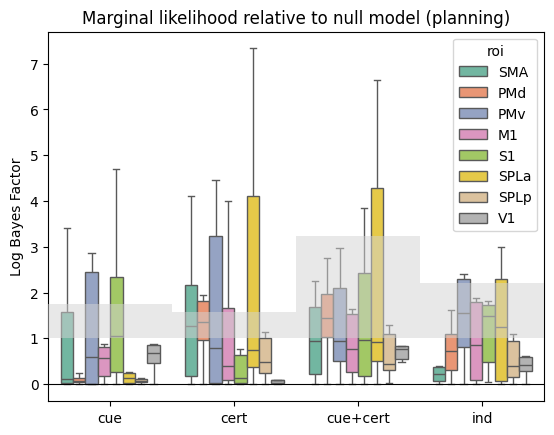

In [23]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

LL = pd.DataFrame()
for roi in rois:

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:,'null'].values
    likelihood = likelihood - baseline.reshape(-1,1)

    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()

    noise_lower_abs = likelihood.ceil.mean()

    assert noise_upper > noise_lower_abs
    print(f'noise upper: {noise_upper:.2f}, noise lower: {noise_lower_abs:.2f}')

    likelihood = likelihood / noise_lower_abs
    noise_upper = noise_upper / noise_lower_abs

    noise_lower = likelihood.ceil.mean()

    # noise_lower = likelihood.ceil.mean()
    # noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()
    
    LL_tmp = pd.melt(likelihood)
    LL_tmp['roi'] = roi
    LL_tmp['noise_lower'] = noise_lower
    LL_tmp['noise_upper'] = noise_upper
    
    LL = pd.concat([LL, LL_tmp])

LL = LL[(LL['model'] == 'cue') | (LL['model'] == 'cert') | (LL['model'] == 'cue+cert') | (LL['model'] == 'ind')]

fig, axs = plt.subplots()

sns.boxplot(ax=axs, x='model', y='value', hue='roi', data=LL, showfliers=False, palette='Set2')

axs.axhline(0, color='k', ls='-', lw=.8)

for r, roi in enumerate(rois):
    
    nl = LL[LL['roi'] == roi]['noise_lower'].unique()[0]
    nu = LL[LL['roi'] == roi]['noise_upper'].unique()[0]
    
    noiserect = patches.Rectangle((r - .5, nl), 1, nu-nl, linewidth=0, facecolor='lightgrey', zorder=1e6, alpha=.5)
    axs.add_patch(noiserect)

axs.set_ylabel('Log Bayes Factor')
axs.set_xlabel('')

axs.set_title('Marginal likelihood relative to null model (planning)')

Text(0.5, 1.0, 'Component model parameters (planning)')

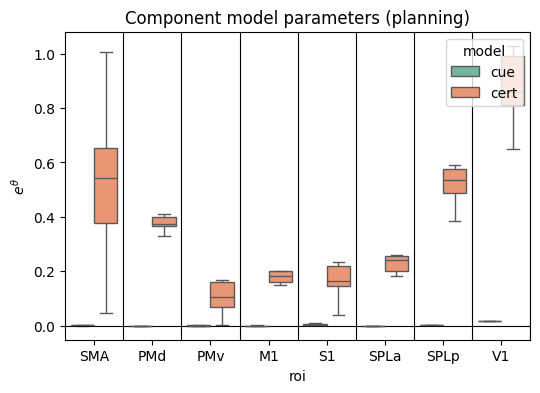

In [13]:
components = ['cue', 'cert']

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
snS=[102, 103, 104, 105, 106, 107]
experiment = 'smp2'

n_param = 2

theta = {
    'sn': [],
    'roi': [],
    'model': [],
    'theta': []
}
for roi in rois:
    
    with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb") as f:
        theta_tmp = pickle.load(f)[3][:n_param]
    
    theta['theta'].extend(np.exp(theta_tmp.flatten()))
    theta['sn'].extend(snS * n_param)
    theta['roi'].extend([roi] * n_param * len(snS))
    theta['model'].extend([mdl for mdl in components for _ in range(len(snS))])

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(figsize=(6, 4))

sns.boxplot(ax=axs, data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set2')

axs.set_ylabel(r"$e^{\theta}$")

for r in range(len(rois)):
    
    axs.axvline(r + .5, color='k', ls='-', lw=.8)

axs.legend(title='model', loc='upper right')
axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

axs.axhline(0, color='k', ls='-', lw=.8)

axs.set_title('Component model parameters (planning)')


### Just zooming into the previous figure to check cue representation:

Text(0.5, 1.0, 'Component model parameters for cue (planning)')

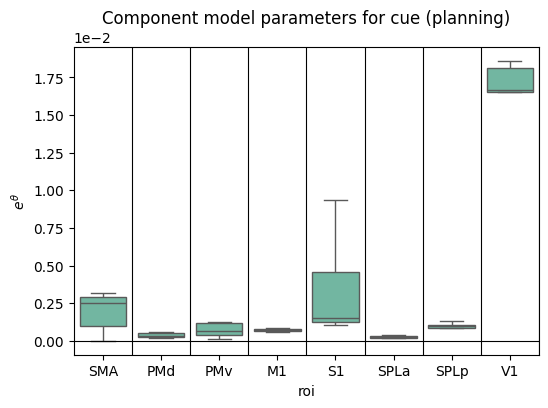

In [14]:
fig, axs = plt.subplots(figsize=(6, 4))

sns.boxplot(ax=axs, data=theta[theta['model']=='cue'], x='roi', y='theta',  showfliers=False, color=plt.cm.Set2(0), legend=False)

axs.set_ylabel(r"$e^{\theta}$")

for r in range(len(rois)):
    
    axs.axvline(r + .5, color='k', ls='-', lw=.8)

axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

axs.axhline(0, color='k', ls='-', lw=.8)

axs.set_title('Component model parameters for cue (planning)')

## Execution

Text(0.5, 0.98, 'Execution models (distance)')

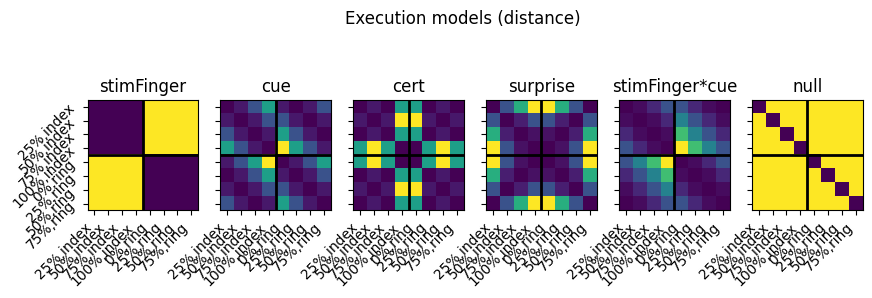

In [34]:
C = pcm.centering(8)

v_fingerID = C @ np.array([1, 1, 1, 1, -1, -1, -1, -1])
v_cue = C @ np.array([-1, 0, 1, 2, -2, -1, 0, 1, ])
v_fingerID_by_cue = C @ (v_fingerID + v_cue)
v_cert = C @ np.array([0.1875, .25, 0.1875, 0, 0, 0.1875, .25, 0.1875])  # variance of a Bernoulli distribution
v_surprise = C @ -np.log2(np.array([.25, .5, .75, 1, 1, .75, .5, .25]))  # with Shannon information

G_fingerID = np.outer(v_fingerID, v_fingerID)
G_cue = np.outer(v_cue, v_cue)
G_fingerID_by_cue = np.outer(v_fingerID_by_cue, v_fingerID_by_cue)
G_cert = np.outer(v_cert, v_cert)
G_surprise = np.outer(v_surprise, v_surprise)

fig, axs = plt.subplots(1, 6, sharex=True, sharey=True, figsize=(10, 3))

axs[0].imshow(pcm.G_to_dist(G_fingerID))
axs[1].imshow(pcm.G_to_dist(G_cue))
axs[2].imshow(pcm.G_to_dist(G_cert))
axs[3].imshow(pcm.G_to_dist(G_surprise))
axs[4].imshow(pcm.G_to_dist(G_fingerID_by_cue))
axs[5].imshow(pcm.G_to_dist(np.eye(8)))

axs[0].set_title('stimFinger')
axs[1].set_title('cue')
axs[2].set_title('cert')
axs[3].set_title('surprise')
axs[4].set_title('stimFinger*cue')
axs[5].set_title('null')

for ax in axs:
    ax.axvline(3.5, color='k', ls='-', lw=2)
    ax.axhline(3.5, color='k', ls='-', lw=2)
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:], rotation=45, ha='right')
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:], rotation=45, ha='right')

fig.suptitle('Execution models (distance)')

In [102]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

LL = pd.DataFrame()
for roi in rois:

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:,'null'].values
    likelihood = likelihood - baseline.reshape(-1,1)
    
    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()
    
    noise_lower_abs = likelihood.ceil.mean()
    likelihood = likelihood / noise_lower_abs
    noise_upper = noise_upper / noise_lower_abs

    noise_lower = likelihood.ceil.mean()
    
    LL_tmp = pd.melt(likelihood)
    LL_tmp['roi'] = roi
    LL_tmp['noise_lower'] = noise_lower
    LL_tmp['noise_upper'] = noise_upper
    
    LL = pd.concat([LL, LL_tmp])

LL = LL[(LL['model'] == 'stimFinger') |
        (LL['model'] == 'cue') | 
        (LL['model'] == 'cert') | 
        (LL['model'] == 'surprise') | 
        (LL['model'] == 'stimFinger+cue+cert+surprise (component)') |
        (LL['model'] == 'stimFinger+cue+cert+surprise (feature)')]

fig, axs = plt.subplots()

sns.boxplot(ax=axs, x='roi', y='value', hue='model', data=LL, showfliers=False, hue_order=['stimFinger','cert', 'cue', 'surprise','stimFinger+cue+cert+surprise (component)', 'stimFinger+cue+cert+surprise (feature)'], palette='Set1')

axs.axhline(0, color='k', ls='-', lw=.8)

for r, roi in enumerate(rois):
    
    nl = LL[LL['roi'] == roi]['noise_lower'].unique()[0]
    nu = LL[LL['roi'] == roi]['noise_upper'].unique()[0]
    
    noiserect = patches.Rectangle((r - .5, nl), 1, nu-nl, linewidth=0, facecolor='lightgrey', zorder=1e6, alpha=.5)
    axs.add_patch(noiserect)
    axs.axvline(r + .5, color='k', ls='-', lw=.8)

axs.set_ylabel('Log Bayes Factor (fraction of noise lower)')
axs.set_xlabel('')

axs.legend(loc='upper center', ncol=2,bbox_to_anchor=(0.5, -0.1))

axs.set_title('Marginal likelihood relative to null model (execution)')

KeyboardInterrupt: 

Text(0.5, 1.0, 'Component model parameters (execution)')

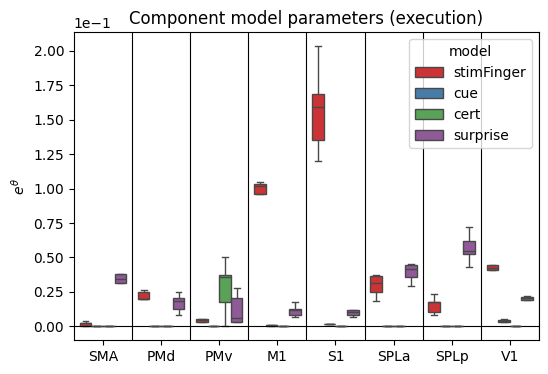

In [89]:
components = ['stimFinger', 'cue', 'cert', 'surprise']

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
snS=[102, 103, 104, 106, 107]
experiment = 'smp2'

n_param = 4

theta = {
    'sn': [],
    'roi': [],
    'model': [],
    'theta': []
}
for roi in rois:
    
    with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb") as f:
        theta_tmp = pickle.load(f)[5][:n_param]
    
    theta['theta'].extend(np.exp(theta_tmp.flatten()))
    theta['sn'].extend(snS * n_param)
    theta['roi'].extend([roi] * n_param * len(snS))
    theta['model'].extend([mdl for mdl in components for _ in range(len(snS))])

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(figsize=(6, 4))

sns.boxplot(ax=axs, data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set1')

axs.set_ylabel(r"$e^{\theta}$")
axs.set_xlabel('')

for r in range(len(rois)):
    
    axs.axvline(r + .5, color='k', ls='-', lw=.8)
    
axs.axhline(0, color='k', ls='-', lw=.8)

axs.legend(title='model', loc='upper right')
axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axs.set_title('Component model parameters (execution)')

Text(0.5, 1.0, 'Feature model parameters (execution)')

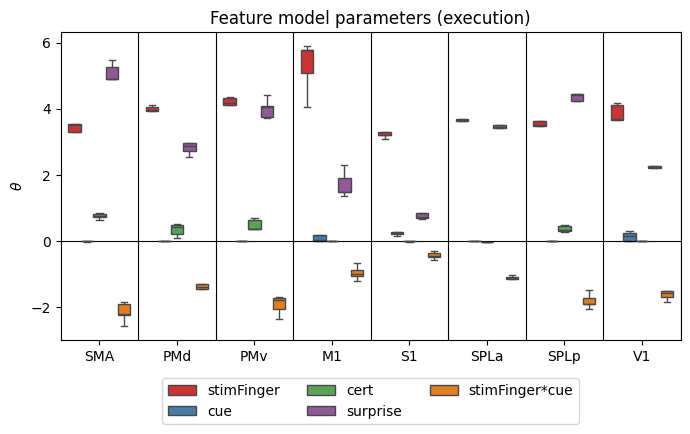

In [84]:
features = ['stimFinger','cue', 'cert', 'surprise', 'stimFinger*cue']

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
snS=[102, 103, 104, 106, 107]
experiment = 'smp2'

n_param = 5

theta = {
    'sn': [],
    'roi': [],
    'model': [],
    'theta': []
}
for roi in rois:
    
    with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb") as f:
        theta_tmp = pickle.load(f)[6][:n_param]
    
    theta['theta'].extend(theta_tmp.flatten())
    theta['sn'].extend(snS * n_param)
    theta['roi'].extend([roi] * n_param * len(snS))
    theta['model'].extend([mdl for mdl in features for _ in range(len(snS))])

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(figsize=(8, 4))

sns.boxplot(ax=axs, data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set1')

axs.set_ylabel(r"$\theta$")
axs.set_xlabel('')

for r in range(len(rois)):
    
    axs.axvline(r + .5, color='k', ls='-', lw=.8)

axs.axhline(0, color='k', ls='-', lw=.8)
axs.legend( loc='upper center', ncol=3, bbox_to_anchor=(0.5, -0.1))
axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axs.set_title('Feature model parameters (execution)')

Text(0.5, 0.98, 'Feature model, predicted distances')

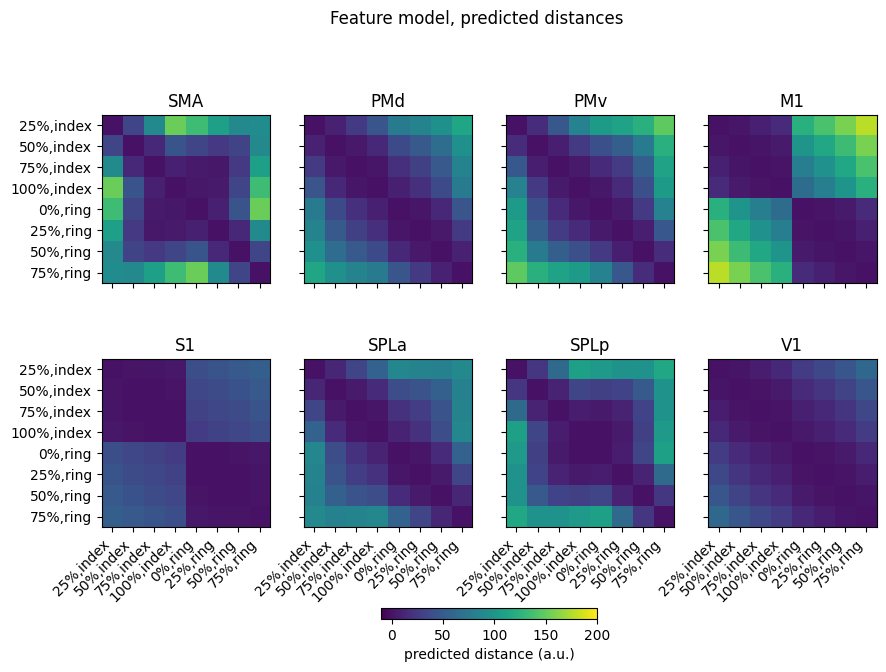

In [77]:
experiment = 'smp2'
glm = 12
H = 'L'
vmin, vmax = -10, 200

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D_obs = pcm.G_to_dist(G_obs.mean(axis=0))
    
    M = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), allow_pickle=True)
    
    theta = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{H}.{roi}.pkl'), allow_pickle=True)
    
    G_hat,_ = M[6].predict(theta[6][:5, 0])
    
    D_hat = pcm.G_to_dist(G_hat)
    
    cax = axs[row, col].imshow(D_hat, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[row, col].set_title(f'{roi}')
    
    ticklabels= list(gl.regressor_mapping.keys())[5:]
    axs[row, col].set_xticks(np.arange(len(ticklabels)))
    axs[row, col].set_yticks(np.arange(len(ticklabels)))
    axs[row, col].set_xticklabels(ticklabels, rotation=45, ha='right')
    axs[row, col].set_yticklabels(ticklabels)

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('predicted distance (a.u.)')

fig.suptitle(f'Feature model, predicted distances')
    

# EMG

[Text(0, 0, '')]

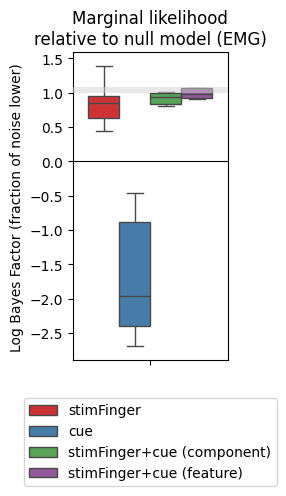

In [86]:
experiment = 'smp0'

LL = pd.DataFrame()

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.Vol.pkl'))
T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.Vol.pkl'))

likelihood = T_cv.likelihood
baseline = likelihood.loc[:,'null'].values
likelihood = likelihood - baseline.reshape(-1,1)

noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()

noise_lower_abs = likelihood.ceil.mean()
likelihood = likelihood / noise_lower_abs
noise_upper = noise_upper / noise_lower_abs

noise_lower = likelihood.ceil.mean()

LL_tmp = pd.melt(likelihood)
LL_tmp['noise_lower'] = noise_lower
LL_tmp['noise_upper'] = noise_upper

LL = pd.concat([LL, LL_tmp])

LL = LL[(LL['model'] == 'stimFinger') |
        (LL['model'] == 'cue') |
        (LL['model'] == 'stimFinger+cue (component)') |
        (LL['model'] == 'stimFinger+cue (feature)')]

fig, axs = plt.subplots(figsize=(2, 4))

sns.boxplot(ax=axs, hue='model', y='value', data=LL, showfliers=False, hue_order=['stimFinger', 'cue', 'stimFinger+cue (component)', 'stimFinger+cue (feature)'], palette='Set1')

axs.axhline(0, color='k', ls='-', lw=.8)

nl = LL['noise_lower'].unique()[0]
nu = LL['noise_upper'].unique()[0]

noiserect = patches.Rectangle((-.5, nl), 6, nu-nl, linewidth=0, facecolor='lightgrey', zorder=1e6, alpha=.5)
axs.add_patch(noiserect)

axs.set_ylabel('Log Bayes Factor (fraction of noise lower)')
axs.set_xlabel('')

axs.legend(loc='upper center', ncol=1,bbox_to_anchor=(0.5, -0.1))

axs.set_title('Marginal likelihood\nrelative to null model (EMG)')

axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha="right")

Text(0.5, 1.0, 'Component model parameters (EMG)')

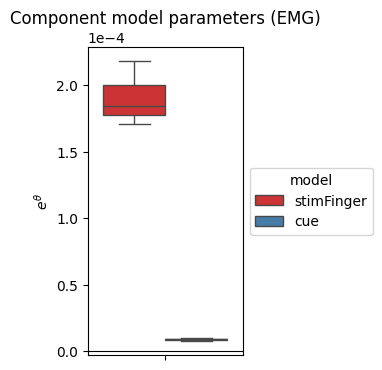

In [87]:
components = ['stimFinger', 'cue']

snS=[100, 101, 102, 104, 105, 106, 107, 108, 109, 110]
experiment = 'smp0'

n_param = 2
    
with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.Vol.pkl'), "rb") as f:
    theta_tmp = pickle.load(f)[3][:n_param]

theta = {}
theta['theta'] = np.exp(theta_tmp.flatten())
theta['sn'] = snS * n_param
theta['model'] = [mdl for mdl in components for _ in range(len(snS))]

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(figsize=(2, 4))

sns.boxplot(ax=axs, data=theta, y='theta', hue='model', showfliers=False, palette='Set1')

axs.set_ylabel(r"$e^{\theta}$")

axs.axhline(0, color='k', ls='-', lw=.8)

axs.legend(title='model', loc='center left', bbox_to_anchor=(1, .5))
axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axs.set_title('Component model parameters (EMG)')

Text(0.5, 1.0, 'Feature model parameters (EMG)')

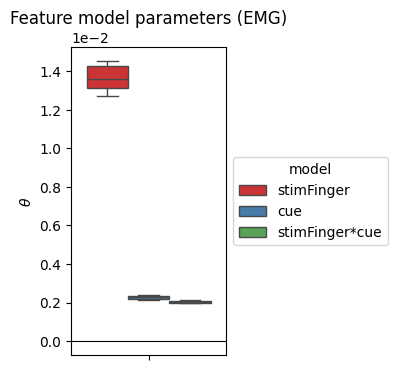

In [88]:
features = ['stimFinger','cue', 'stimFinger*cue', ]

snS=[100, 101, 102, 104, 105, 106, 107, 108, 109, 110]
experiment = 'smp0'

n_param = 3
    
with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.Vol.pkl'), "rb") as f:
    theta_tmp = pickle.load(f)[4][:n_param]

theta = {}
theta['theta'] = theta_tmp.flatten()
theta['sn'] = snS * n_param
theta['model'] = [mdl for mdl in features for _ in range(len(snS))]

theta = pd.DataFrame(theta)

fig, axs = plt.subplots(figsize=(2, 4))

sns.boxplot(ax=axs, data=theta, y='theta', hue='model', showfliers=False, palette='Set1')

axs.set_ylabel(r"$\theta$")

axs.axhline(0, color='k', ls='-', lw=.8)

axs.legend(title='model', loc='center left', ncol=1, bbox_to_anchor=(1, .5))
axs.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axs.set_title('Feature model parameters (EMG)')

In [ ]:
experiment = 'smp0'

G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.Vol.npy'))